# BERT Bias Classification – Source Domain Diagnosis

## Objective
Diagnose whether the BERT attention-based bias classifier learns **true bias signals** or **domain/style artifacts** from the dataset source.

### Dataset: `bias_sentences_mixed.json` (5500 entries)
Composed of 3 sources (reconstructed by cross-referencing `bias_sentences.json`):
- **local**: entries present in the original `bias_sentences.json` (Gemini-generated)
- **biased-corpus**: biased entries with category-style labels (nationality, racial, gender, etc.)
- **gus-dataset-v1**: entries with GUS-Net labels (generalization/unfairness/stereotype) + external neutrals

### Methodology (identical to `bert_bias_classification.ipynb`)
- **Features**: existing `feature_matrix_bert_mixed.pkl` (3238 features via `extract_features_for_sentence`)
- **Pipeline**: `VarianceThreshold(0.01) → StandardScaler → Classifier`
- **CV**: `StratifiedGroupKFold(n_splits=5)` with text-based groups
- **Tuning**: `HalvingRandomSearchCV`

### Diagnostic Tests
1. **Leave-One-Source-Out (LOSO)**: Train on 2 sources, test on the 3rd
2. **Source Classifier**: Predict dataset origin using the same attention features
3. **Full Metrics**: Confusion matrix, precision, recall, F1, AUC
4. **Error Analysis**: 5–10 errors analyzed by type

## 1. Setup & Imports

In [87]:
import subprocess
import sys
import os

try:
    import xgboost
except ImportError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost'])

In [88]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from collections import Counter

# ML Imports
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import (
    StratifiedGroupKFold, GroupShuffleSplit,
    cross_validate, train_test_split, HalvingRandomSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier

# Project Imports
current_dir = os.getcwd()
if 'attention_app' in current_dir:
    while 'attention_app' in current_dir and os.path.basename(current_dir) != 'attention-atlas':
        current_dir = os.path.dirname(current_dir)
    root_dir = current_dir
else:
    root_dir = current_dir

if root_dir not in sys.path:
    sys.path.append(root_dir)

from attention_app.models import ModelManager
from attention_app.bias.feature_extraction_notebooks import extract_features_for_sentence

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports complete")

Imports complete


## 2. Load Dataset & Reconstruct Source Labels

The `bias_sentences_mixed.json` file does not have a `source` field.
We reconstruct it by cross-referencing with `bias_sentences.json`:

- If text exists in `bias_sentences.json` → **local** (Gemini-generated)
- Else if `bias_type` contains generalization/unfairness/stereotype → **gus-dataset-v1**
- Else if `has_bias=False` (external neutral) → **gus-dataset-v1**
- Else (biased with category label) → **biased-corpus**

In [89]:
# Load bias_sentences_mixed.json (5500 entries)
mixed_path = os.path.join(root_dir, 'dataset', 'bias_sentences_mixed.json')
with open(mixed_path, 'r', encoding='utf-8') as f:
    mixed_data = json.load(f)

df_sentences = pd.DataFrame(mixed_data['entries'])
df_sentences['label'] = df_sentences['has_bias'].astype(int)
print(f"Mixed dataset: {len(df_sentences)} entries")
print(f"Label distribution: {df_sentences['label'].value_counts().to_dict()}")

# Load bias_sentences.json (original, for source reconstruction)
orig_path = os.path.join(root_dir, 'dataset', 'bias_sentences.json')
with open(orig_path, 'r', encoding='utf-8') as f:
    orig_data = json.load(f)

orig_texts = set(e['text'] for e in orig_data['entries'])
print(f"Original dataset: {len(orig_data['entries'])} entries, {len(orig_texts)} unique texts")

# Reconstruct source labels
gus_keywords = ['generalization', 'unfairness', 'stereotype']

def assign_source(row):
    # 1. If text exists in original bias_sentences.json -> local
    if row['text'] in orig_texts:
        return 'local'
    
    # 2. If bias_type contains GUS-Net keywords -> gus-dataset-v1
    bt = str(row.get('bias_type', '') or '')
    if any(kw in bt for kw in gus_keywords):
        return 'gus-dataset-v1'
    
    # 3. If neutral and not in original -> gus-dataset-v1 (external neutral)
    if not row['has_bias']:
        return 'gus-dataset-v1'
    
    # 4. Otherwise -> biased-corpus (biased with category label)
    return 'biased-corpus'

df_sentences['source'] = df_sentences.apply(assign_source, axis=1)

print(f"\nReconstructed source distribution:")
print(df_sentences['source'].value_counts())

print(f"\nBias by source:")
print(pd.crosstab(df_sentences['source'], df_sentences['has_bias'], margins=True))

# Duplicate analysis
n_unique = df_sentences['text'].nunique()
print(f"\nUnique texts: {n_unique} / {len(df_sentences)}")
df_sentences = df_sentences.drop_duplicates(subset=['text']).reset_index(drop=True)
print(f"After dedup: {len(df_sentences)} rows")

Mixed dataset: 5500 entries
Label distribution: {0: 2750, 1: 2750}
Original dataset: 5147 entries, 4011 unique texts

Reconstructed source distribution:
source
biased-corpus     2476
local             2317
gus-dataset-v1     707
Name: count, dtype: int64

Bias by source:
has_bias        False  True   All
source                           
biased-corpus       0  2476  2476
gus-dataset-v1    433   274   707
local            2317     0  2317
All              2750  2750  5500

Unique texts: 5500 / 5500
After dedup: 5500 rows


## 3. Load Feature Matrix

Load the existing `feature_matrix_bert_mixed.pkl` (extracted with `extract_features_for_sentence`, 3238 features).
This pkl was extracted from the same 5500-entry mixed dataset.

In [90]:
# Load feature matrix
features_path = os.path.join(root_dir, 'attention_app', 'bias', 'extracted_features', 'feature_matrix_bert_mixed.pkl')

if not os.path.exists(features_path):
    raise FileNotFoundError(
        f"Feature matrix not found at {features_path}.\n"
        "Run feature extraction in bert_bias_classification.ipynb first."
    )

df_features = pd.read_pickle(features_path)
print(f"Feature matrix: {df_features.shape[0]} samples x {df_features.shape[1]} features")

# Validate size matches
if len(df_features) != len(df_sentences):
    raise RuntimeError(
        f"Size mismatch: pkl has {len(df_features)} rows but "
        f"bias_sentences_mixed.json has {len(df_sentences)} rows after dedup.\n"
        "Re-run feature extraction for the current dataset."
    )

# Align text + source from df_sentences (by position)
df_features['text'] = df_sentences['text'].values
df_features['source'] = df_sentences['source'].values
df_features['id'] = df_sentences['id'].values if 'id' in df_sentences.columns else range(len(df_features))

print(f"Aligned with bias_sentences_mixed.json")
print(f"Unique texts: {df_features['text'].nunique()} / {len(df_features)}")
print(f"Sources: {df_features['source'].value_counts().to_dict()}")

Feature matrix: 5500 samples x 3239 features
Aligned with bias_sentences_mixed.json
Unique texts: 5500 / 5500
Sources: {'biased-corpus': 2476, 'local': 2317, 'gus-dataset-v1': 707}


## 4. Prepare Data for Modeling

In [91]:
# Separate features and labels
drop_cols = ['label', 'id', 'text', 'source', 'original_id']
X = df_features.drop(columns=[c for c in drop_cols if c in df_features.columns])
y = df_features['label']
sources = df_features['source'].values

# Text-based groups for leakage-free splitting
text_to_group = {t: i for i, t in enumerate(df_features['text'].unique())}
groups = df_features['text'].map(text_to_group).values

print(f"Total features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")
print(f"Unique groups (texts): {len(text_to_group)}")
print(f"\nSource distribution:")
for src, cnt in Counter(sources).most_common():
    src_labels = y[sources == src]
    print(f"  {src:20} {cnt:5d} (biased={src_labels.sum()}, neutral={(~src_labels.astype(bool)).sum()})")

print(f"\nLabel distribution: biased={y.sum()}, neutral={(~y.astype(bool)).sum()}")
print(f"Feature columns (first 10): {list(X.columns[:10])}")

X_final = X.copy()

Total features: 3238
Total samples: 5500
Unique groups (texts): 5500

Source distribution:
  biased-corpus         2476 (biased=2476, neutral=0)
  local                 2317 (biased=0, neutral=2317)
  gus-dataset-v1         707 (biased=274, neutral=433)

Label distribution: biased=2750, neutral=2750
Feature columns (first 10): ['GAM_L0_H0_confidence_max', 'GAM_L0_H0_confidence_avg', 'GAM_L0_H0_focus_entropy', 'GAM_L0_H0_sparsity', 'GAM_L0_H0_distribution_median', 'GAM_L0_H0_distribution_q25', 'GAM_L0_H0_distribution_q75', 'GAM_L0_H0_uniformity', 'GAM_L0_H0_balance', 'GAM_L0_H0_focus_normalized']


## 5. Leave-One-Source-Out (LOSO) Cross-Validation

Train on 2 sources, test on the held-out source.
Uses the **same pipeline** as `bert_bias_classification.ipynb`.
Internal CV with `StratifiedGroupKFold` on the training sources.

In [72]:
unique_sources = np.unique(sources)
print(f"Sources for LOSO: {unique_sources}\n")

loso_results = []

for test_source in unique_sources:
    print(f"{'='*70}")
    print(f"LOSO Fold: Test on [{test_source}]")
    print(f"{'='*70}")
    
    # Source-based split
    test_mask = sources == test_source
    train_mask = ~test_mask
    
    X_train = X_final.iloc[np.where(train_mask)[0]]
    X_test = X_final.iloc[np.where(test_mask)[0]]
    y_train = y.iloc[np.where(train_mask)[0]]
    y_test = y.iloc[np.where(test_mask)[0]]
    groups_train = groups[train_mask]
    
    train_source_list = np.unique(sources[train_mask])
    
    print(f"  Train: {len(X_train)} samples from {train_source_list}")
    print(f"  Test:  {len(X_test)} samples from {test_source}")
    print(f"  Train: biased={y_train.sum()}, neutral={(~y_train.astype(bool)).sum()}")
    print(f"  Test:  biased={y_test.sum()}, neutral={(~y_test.astype(bool)).sum()}")
    
    # Pipeline (same as original)
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx',
            max_depth=8,
            n_estimators=500,
            learning_rate=0.05,
            min_child_weight=1,
            gamma=0.1,
            reg_alpha=0.1,
            reg_lambda=1.0,
            eval_metric='logloss',
            random_state=RANDOM_STATE
        ))
    ])
    
    # Internal CV on training sources (only if both classes present)
    if len(np.unique(y_train)) > 1:
        cv = StratifiedGroupKFold(n_splits=5)
        scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
        cv_scores = cross_validate(
            pipeline, X_train, y_train, cv=cv, scoring=scoring,
            groups=groups_train
        )
        print(f"\n  Internal CV (train sources):")
        print(f"    AUC:  {cv_scores['test_roc_auc'].mean():.4f} (+/- {cv_scores['test_roc_auc'].std():.4f})")
        print(f"    F1:   {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std():.4f})")
    
    # Fit on full training set
    pipeline.fit(X_train, y_train)
    
    # Predict on held-out source
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) > 1 else np.nan
    
    print(f"\n  Held-out Test Results [{test_source}]:")
    print(f"    Accuracy:  {acc:.4f}")
    print(f"    Precision: {prec:.4f}")
    print(f"    Recall:    {rec:.4f}")
    print(f"    F1:        {f1:.4f}")
    if not np.isnan(auc):
        print(f"    AUC:       {auc:.4f}")
    else:
        print(f"    AUC:       N/A (single class in test)")
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:")
    print(f"    {cm}")
    
    # Classification report
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    loso_results.append({
        'test_source': test_source,
        'train_sources': ', '.join(train_source_list),
        'n_train': len(X_train),
        'n_test': len(X_test),
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

Sources for LOSO: ['biased-corpus' 'gus-dataset-v1' 'local']

LOSO Fold: Test on [biased-corpus]
  Train: 3024 samples from ['gus-dataset-v1' 'local']
  Test:  2476 samples from biased-corpus
  Train: biased=274, neutral=2750
  Test:  biased=2476, neutral=0

  Internal CV (train sources):
    AUC:  0.9437 (+/- 0.0106)
    F1:   0.4930 (+/- 0.0555)

  Held-out Test Results [biased-corpus]:
    Accuracy:  0.4649
    Precision: 1.0000
    Recall:    0.4649
    F1:        0.6347
    AUC:       N/A (single class in test)

  Confusion Matrix:
    [[   0    0]
 [1325 1151]]

  Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.46      0.63      2476

    accuracy                           0.46      2476
   macro avg       0.50      0.23      0.32      2476
weighted avg       1.00      0.46      0.63      2476

LOSO Fold: Test on [gus-dataset-v1]
  Train: 4793 samples from ['biased-c

LOSO SUMMARY
   test_source  n_train  n_test  accuracy  precision   recall       f1      auc
 biased-corpus     3024    2476  0.464863   1.000000 0.464863 0.634684      NaN
gus-dataset-v1     4793     707  0.404526   0.391433 0.967153 0.557308 0.564644
         local     3183    2317  0.011653   0.000000 0.000000 0.000000      NaN

Mean across folds:
accuracy     0.293681
precision    0.463811
recall       0.477339
f1           0.397331
auc          0.564644
dtype: float64


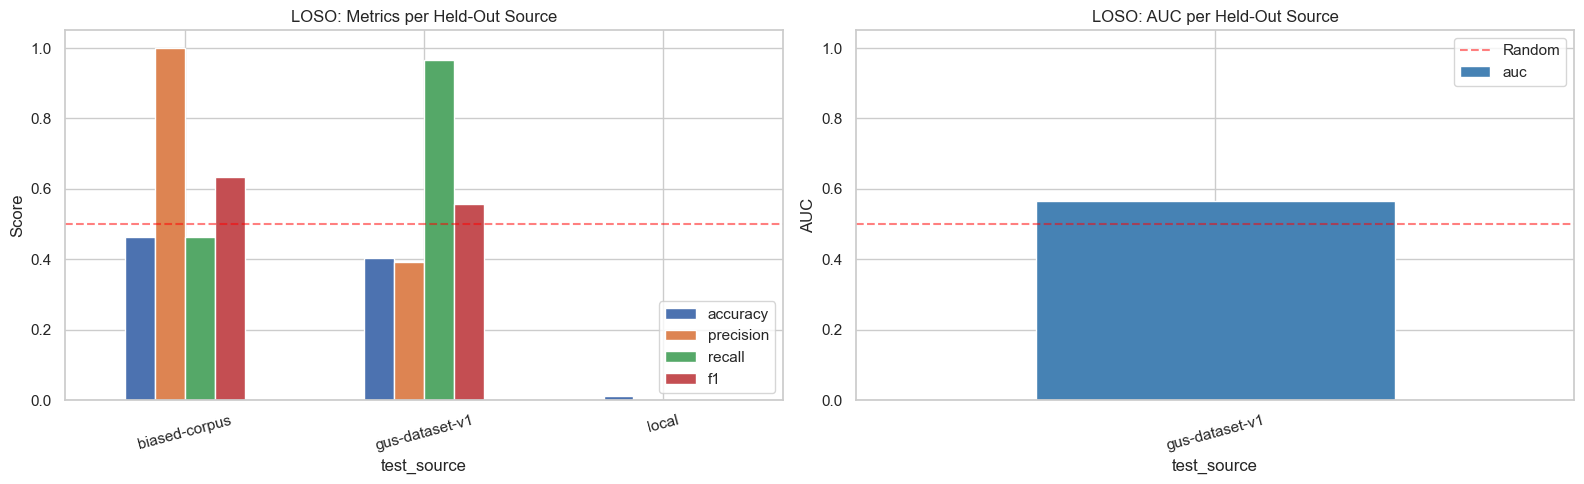

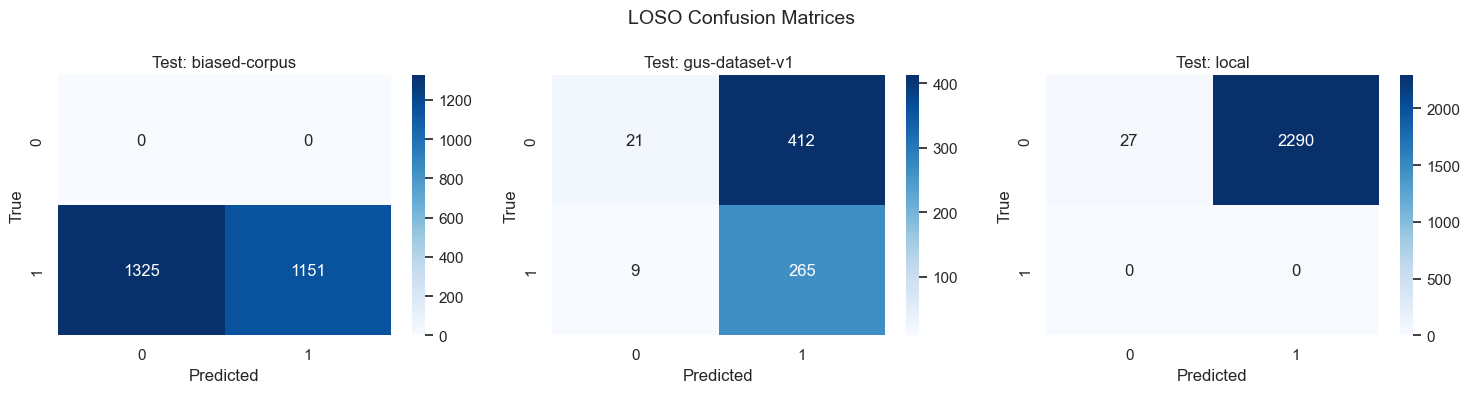

In [73]:
# LOSO Summary Table
print(f"{'='*70}")
print("LOSO SUMMARY")
print(f"{'='*70}")

df_loso = pd.DataFrame(loso_results)
print(df_loso[['test_source', 'n_train', 'n_test', 'accuracy', 'precision', 'recall', 'f1', 'auc']].to_string(index=False))

print(f"\nMean across folds:")
print(df_loso[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean())

# Plot LOSO results
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
df_loso_plot = df_loso.set_index('test_source')[metrics_to_plot]
df_loso_plot.plot(kind='bar', ax=axes[0], rot=15)
axes[0].set_title('LOSO: Metrics per Held-Out Source')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc='lower right')
axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

# AUC bar chart
df_loso_auc = df_loso.set_index('test_source')[['auc']].dropna()
df_loso_auc.plot(kind='bar', ax=axes[1], rot=15, color='steelblue')
axes[1].set_title('LOSO: AUC per Held-Out Source')
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0, 1.05)
axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random')
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot all confusion matrices
n_sources = len(df_loso)
fig, axes = plt.subplots(1, n_sources, figsize=(5 * n_sources, 4))
if n_sources == 1:
    axes = [axes]
for i, row in df_loso.iterrows():
    cm = np.array(row['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f"Test: {row['test_source']}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

plt.suptitle('LOSO Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Source Classifier: Predict Dataset Origin

Train a multi-class classifier to predict the **source** of each sentence using the same attention features.
If accuracy >> 33% (random baseline for 3 classes), features encode source/domain information.

Source labels: ['biased-corpus' 'gus-dataset-v1' 'local']
Source distribution: {2: 2317, 0: 2476, 1: 707}
Random baseline: 33.3%

Train: 4125 | Test: 1375

Training source classifiers (3-way)...
  LogReg          CV Accuracy: 0.9059 (+/- 0.0049)
  LogReg          Test Accuracy: 0.9018
  XGBoost         CV Accuracy: 0.9016 (+/- 0.0058)
  XGBoost         Test Accuracy: 0.9098

Source Classifier (XGBoost) - Test Accuracy: 0.9098
Random baseline: 0.3333 (3 classes)

Classification Report:
                precision    recall  f1-score   support

 biased-corpus       0.88      0.96      0.92       631
gus-dataset-v1       0.92      0.57      0.71       171
         local       0.95      0.96      0.95       573

      accuracy                           0.91      1375
     macro avg       0.91      0.83      0.86      1375
  weighted avg       0.91      0.91      0.90      1375

Confusion Matrix:
                biased-corpus  gus-dataset-v1  local
biased-corpus             604               

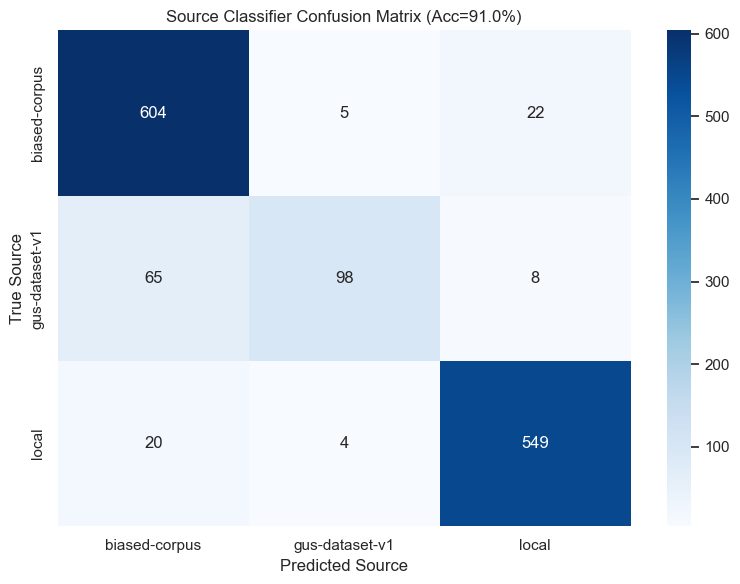


  BERT features encode source/domain information.
  The bias classifier may use domain artifacts as shortcuts.


In [74]:
# Encode sources
le = LabelEncoder()
y_source = le.fit_transform(sources)

print(f"Source labels: {le.classes_}")
print(f"Source distribution: {dict(Counter(y_source))}")
print(f"Random baseline: {1/len(le.classes_):.1%}")

# Group-based split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx_src, test_idx_src = next(gss.split(X_final, y_source, groups=groups))

X_train_src = X_final.iloc[train_idx_src]
X_test_src = X_final.iloc[test_idx_src]
y_train_src = y_source[train_idx_src]
y_test_src = y_source[test_idx_src]
groups_train_src = groups[train_idx_src]

print(f"\nTrain: {len(X_train_src)} | Test: {len(X_test_src)}")

# Source classifiers
src_models = {
    'LogReg': LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='multinomial'),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, eval_metric='mlogloss', random_state=RANDOM_STATE
    ),
}

print(f"\nTraining source classifiers ({len(le.classes_)}-way)...")
cv_src = StratifiedGroupKFold(n_splits=5)

best_src_pred = None
best_src_acc = 0

for name, model in src_models.items():
    src_pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model)
    ])
    
    cv_scores = cross_validate(
        src_pipeline, X_train_src, y_train_src,
        cv=cv_src, scoring='accuracy', groups=groups_train_src
    )
    print(f"  {name:15} CV Accuracy: {cv_scores['test_score'].mean():.4f} (+/- {cv_scores['test_score'].std():.4f})")
    
    src_pipeline.fit(X_train_src, y_train_src)
    y_pred_src = src_pipeline.predict(X_test_src)
    acc = accuracy_score(y_test_src, y_pred_src)
    print(f"  {name:15} Test Accuracy: {acc:.4f}")
    
    if acc > best_src_acc:
        best_src_pred = y_pred_src
        best_src_acc = acc
        best_src_name = name

# Detailed report
print(f"\n{'='*60}")
print(f"Source Classifier ({best_src_name}) - Test Accuracy: {best_src_acc:.4f}")
print(f"Random baseline: {1/len(le.classes_):.4f} ({len(le.classes_)} classes)")
print(f"{'='*60}")

print(f"\nClassification Report:")
print(classification_report(y_test_src, best_src_pred, target_names=le.classes_, zero_division=0))

cm_src = confusion_matrix(y_test_src, best_src_pred)
print(f"Confusion Matrix:")
print(pd.DataFrame(cm_src, index=le.classes_, columns=le.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_src, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Source')
plt.ylabel('True Source')
plt.title(f'Source Classifier Confusion Matrix (Acc={best_src_acc:.1%})')
plt.tight_layout()
plt.show()

if best_src_acc > 0.5:
    print(f"\nWARNING: Source classifier achieves {best_src_acc:.1%} accuracy (baseline={1/len(le.classes_):.1%})!")
    print(f"  BERT features encode source/domain information.")
    print(f"  The bias classifier may use domain artifacts as shortcuts.")
else:
    print(f"\nSource classifier accuracy is low ({best_src_acc:.1%}).")
    print(f"  Features do not strongly encode source information.")

## 7. Error Analysis: Bias Classifier

Train bias classifier with `GroupShuffleSplit` + `StratifiedGroupKFold` + `HalvingRandomSearchCV` (same as original notebook), then analyze errors by source and text type.

In [92]:
# Group-based train/test split (same as original notebook)
gss_bias = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss_bias.split(X_final, y, groups=groups))

X_train = X_final.iloc[train_idx]
X_test = X_final.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]
groups_train = groups[train_idx]

# Verify no text leakage
train_texts = set(df_features.iloc[train_idx]['text'])
test_texts_set = set(df_features.iloc[test_idx]['text'])
overlap = train_texts & test_texts_set
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Text overlap: {len(overlap)} (should be 0)")
assert len(overlap) == 0, "LEAKAGE DETECTED!"

# Model comparison (same models as original)
models = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, min_child_weight=1, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0, eval_metric='logloss',
        random_state=RANDOM_STATE
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15, alpha=0.01,
        random_state=RANDOM_STATE
    )
}

results = {}
cv = StratifiedGroupKFold(n_splits=5)

print("\nComparing Models (StratifiedGroupKFold, VT inside pipeline)")
for name, model in models.items():
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model)
    ])
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(
        pipeline, X_train, y_train, cv=cv, scoring=scoring,
        groups=groups_train
    )
    mean_auc = scores['test_roc_auc'].mean()
    mean_acc = scores['test_accuracy'].mean()
    mean_prec = scores['test_precision'].mean()
    mean_rec = scores['test_recall'].mean()
    mean_f1 = scores['test_f1'].mean()
    results[name] = {'auc': mean_auc, 'accuracy': mean_acc, 'precision': mean_prec, 'recall': mean_rec, 'f1': mean_f1}
    print(f"{name:15} | AUC: {mean_auc:.4f} | Acc: {mean_acc:.4f} | Prec: {mean_prec:.4f} | Rec: {mean_rec:.4f} | F1: {mean_f1:.4f}")

best_model_name = max(results, key=lambda x: results[x]['auc'])
print(f"\nBest Model: {best_model_name} (AUC={results[best_model_name]['auc']:.4f})")

Train: 4125 | Test: 1375
Text overlap: 0 (should be 0)

Comparing Models (StratifiedGroupKFold, VT inside pipeline)
LogReg          | AUC: 0.9741 | Acc: 0.9222 | Prec: 0.9196 | Rec: 0.9244 | F1: 0.9219
RandomForest    | AUC: 0.9611 | Acc: 0.8861 | Prec: 0.8720 | Rec: 0.9039 | F1: 0.8876
XGBoost         | AUC: 0.9758 | Acc: 0.9181 | Prec: 0.9009 | Rec: 0.9385 | F1: 0.9193
MLP             | AUC: 0.9766 | Acc: 0.9222 | Prec: 0.9202 | Rec: 0.9244 | F1: 0.9220

Best Model: MLP (AUC=0.9766)


In [93]:
# Hyperparameter Tuning (same as original notebook)
print(f"Tuning {best_model_name}...")

param_grids = {
    'RandomForest': {
        'm__n_estimators': [50, 100, 200],
        'm__max_depth': [None, 10, 20],
        'm__min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'm__n_estimators': [50, 100, 200],
        'm__learning_rate': [0.01, 0.1, 0.2],
        'm__max_depth': [3, 5, 7]
    },
    'MLP': {
        'm__hidden_layer_sizes': [(32,), (50,), (64,), (32, 16), (50, 25)],
        'm__alpha': [0.01, 0.05, 0.1, 0.2, 0.5],
        'm__learning_rate_init': [0.001, 0.005, 0.01],
        'm__activation': ['relu', 'tanh'],
        'm__solver': ['adam'],
        'm__early_stopping': [True],
        'm__validation_fraction': [0.15],
        'm__n_iter_no_change': [15],
    },
    'LogReg': {
        'm__C': [0.1, 1.0, 10.0]
    }
}

pipeline = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models[best_model_name])
])

cv_tuning = StratifiedGroupKFold(n_splits=5)
search = HalvingRandomSearchCV(
    pipeline,
    param_distributions=param_grids[best_model_name],
    cv=cv_tuning,
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE
)
search.fit(X_train, y_train, groups=groups_train)

print(f"Best Params: {search.best_params_}")
final_model = search.best_estimator_

Tuning MLP...
Best Params: {'m__validation_fraction': 0.15, 'm__solver': 'adam', 'm__n_iter_no_change': 15, 'm__learning_rate_init': 0.005, 'm__hidden_layer_sizes': (50,), 'm__early_stopping': True, 'm__alpha': 0.01, 'm__activation': 'relu'}


Final Test Set Results (Group-Based Split)
AUC:       0.9893
Accuracy:  0.9462
Precision: 0.9446
Recall:    0.9500
F1:        0.9473

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       675
           1       0.94      0.95      0.95       700

    accuracy                           0.95      1375
   macro avg       0.95      0.95      0.95      1375
weighted avg       0.95      0.95      0.95      1375



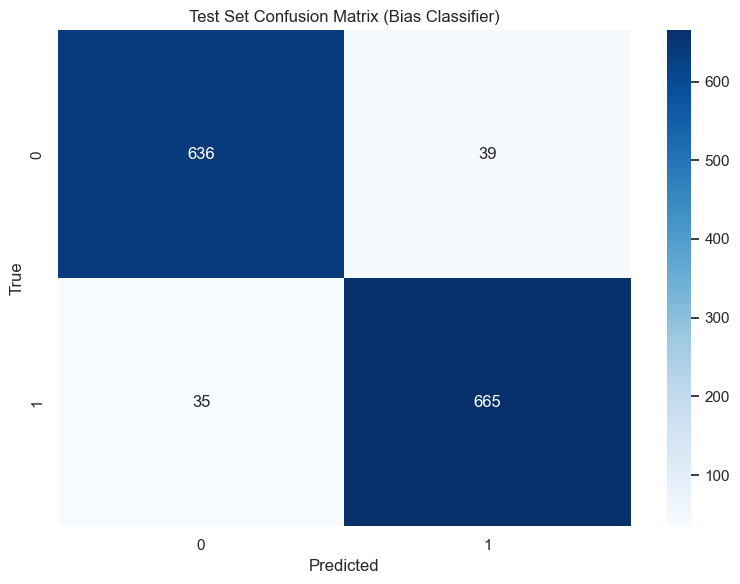

In [94]:
# Final Test Evaluation
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)[:, 1]

print("Final Test Set Results (Group-Based Split)")
print(f"AUC:       {roc_auc_score(y_test, y_test_prob):.4f}")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"F1:        {f1_score(y_test, y_test_pred, zero_division=0):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Test Set Confusion Matrix (Bias Classifier)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
plt.show()

In [95]:
# Error Analysis by Source and Text Type
test_texts = df_features.iloc[test_idx]['text'].values
test_sources = df_features.iloc[test_idx]['source'].values

errors_mask = y_test.values != y_test_pred
false_positives = (y_test.values == 0) & (y_test_pred == 1)
false_negatives = (y_test.values == 1) & (y_test_pred == 0)

print(f"Total test: {len(y_test)}")
print(f"Total errors: {errors_mask.sum()} ({errors_mask.sum()/len(y_test)*100:.2f}%)")
print(f"  False Positives (neutral -> biased): {false_positives.sum()}")
print(f"  False Negatives (biased -> neutral): {false_negatives.sum()}")

# Errors by source
print(f"\nErrors by source:")
print(f"  {'Source':20} {'Errors':>6} / {'Total':>6}  {'Rate':>6}")
for source in unique_sources:
    source_mask = test_sources == source
    source_errors = errors_mask & source_mask
    source_total = source_mask.sum()
    if source_total > 0:
        rate = source_errors.sum() / source_total
        print(f"  {source:20} {source_errors.sum():6d} / {source_total:6d}  {rate*100:5.1f}%")

# Build error DataFrame
error_df = pd.DataFrame({
    'text': test_texts[errors_mask],
    'true_label': y_test.values[errors_mask],
    'pred_label': y_test_pred[errors_mask],
    'source': test_sources[errors_mask],
})

def classify_text_type(text):
    text_lower = text.lower().strip()
    if text_lower.endswith('?') or text_lower.startswith(('what', 'why', 'how', 'when', 'where', 'who', 'can', 'is', 'are', 'do', 'does')):
        return 'question'
    if any(kw in text_lower for kw in ['study', 'research', 'data', 'evidence', 'analysis', 'experiment', 'theory', 'hypothesis']):
        return 'technical/scientific'
    if any(text_lower.startswith(p) for p in ['that person', 'they', 'someone', 'a person']):
        return 'neutral_descriptive'
    return 'statement'

error_df['text_type'] = error_df['text'].apply(classify_text_type)
error_df['error_type'] = error_df['true_label'].map({0: 'FP (neutral->biased)', 1: 'FN (biased->neutral)'})

print(f"\nErrors by text type:")
print(pd.crosstab(error_df['text_type'], error_df['error_type'], margins=True))

Total test: 1375
Total errors: 74 (5.38%)
  False Positives (neutral -> biased): 39
  False Negatives (biased -> neutral): 35

Errors by source:
  Source               Errors /  Total    Rate
  biased-corpus            21 /    631    3.3%
  gus-dataset-v1           32 /    171   18.7%
  local                    21 /    573    3.7%

Errors by text type:
error_type            FN (biased->neutral)  FP (neutral->biased)  All
text_type                                                            
neutral_descriptive                      2                     1    3
question                                10                     4   14
statement                               22                    32   54
technical/scientific                     1                     2    3
All                                     35                    39   74


In [79]:
# Sample Errors: 5 False Positives + 5 False Negatives
print(f"{'='*80}")
print("SAMPLE ERRORS")
print(f"{'='*80}")

fp_df = error_df[error_df['true_label'] == 0]
fp_sample = fp_df.sample(n=min(5, len(fp_df)), random_state=RANDOM_STATE) if len(fp_df) > 0 else fp_df
print(f"\nFalse Positives (neutral predicted as biased): {len(fp_df)} total")
for _, row in fp_sample.iterrows():
    print(f"\n  [{row['source']}] ({row['text_type']})")
    print(f"  {row['text']}")

fn_df = error_df[error_df['true_label'] == 1]
fn_sample = fn_df.sample(n=min(5, len(fn_df)), random_state=RANDOM_STATE) if len(fn_df) > 0 else fn_df
print(f"\n\nFalse Negatives (biased predicted as neutral): {len(fn_df)} total")
for _, row in fn_sample.iterrows():
    print(f"\n  [{row['source']}] ({row['text_type']})")
    print(f"  {row['text']}")

# Save full error analysis
error_df.to_csv("error_analysis_source_diagnosis.csv", index=False)
print(f"\nFull error analysis saved to error_analysis_source_diagnosis.csv ({len(error_df)} errors)")

SAMPLE ERRORS

False Positives (neutral predicted as biased): 39 total

  [gus-dataset-v1] (statement)
  "You think I'm joking," he continued. "

  [local] (statement)
  Glaciers store about 69 percent of the world's fresh water supply.

  [gus-dataset-v1] (statement)
  For those fortunate enough to live openly as their authentic selves, daily interactions like using public restrooms or filling prescriptions at pharmacies can still pose uncomfortable situations.

  [local] (statement)
  People shared their cultural traditions respectfully.

  [gus-dataset-v1] (statement)
  The idea of exposing your child to something that could potentially harm her, and in a catastrophic way, is terrifying.


False Negatives (biased predicted as neutral): 35 total

  [gus-dataset-v1] (statement)
  The White House is cynically harnessing the coronavirus panic in a complete image makeover.

  [biased-corpus] (statement)
  Christian morals set the standard for ethical behavior.

  [biased-corpus] (stateme

## 8. Residualization: Remove Source Signal from Features

For each feature, regress it against source (one-hot), keep only the **residuals**.
The residuals contain whatever information the feature carries that is **not** explained by source membership.

If the bias classifier still works on residuals, the model learned real bias signals.
If it collapses, the model was only learning source artifacts.

In [80]:
from sklearn.linear_model import LinearRegression

# One-hot encode source
source_dummies = pd.get_dummies(df_features['source'], drop_first=False).values  # (5500, 3)
print(f"Source dummies shape: {source_dummies.shape}")
print(f"Original features shape: {X_final.shape}")

# Residualize: for each feature, regress out the source effect
X_residual = X_final.copy()
lr = LinearRegression()

for col in X_final.columns:
    feature_values = X_final[col].values.reshape(-1, 1)
    lr.fit(source_dummies, feature_values)
    predicted_by_source = lr.predict(source_dummies)
    X_residual[col] = feature_values.ravel() - predicted_by_source.ravel()

print(f"\nResidualized features shape: {X_residual.shape}")

# Verify: source classifier on residuals should fail
le_check = LabelEncoder()
y_source_check = le_check.fit_transform(sources)

src_pipe_check = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', LogisticRegression(solver='lbfgs', max_iter=1000, multi_class='multinomial'))
])

gss_check = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss_check.split(X_residual, y_source_check, groups=groups))
src_pipe_check.fit(X_residual.iloc[tr_idx], y_source_check[tr_idx])
src_acc_residual = accuracy_score(y_source_check[te_idx], src_pipe_check.predict(X_residual.iloc[te_idx]))

print(f"\nSource classifier accuracy:")
print(f"  Before residualization: (see Section 6 above)")
print(f"  After residualization:  {src_acc_residual:.4f}")
print(f"  Random baseline:        {1/len(le_check.classes_):.4f}")

if src_acc_residual < 0.40:
    print(f"\n  Source signal successfully removed from features.")
else:
    print(f"\n  WARNING: Source signal partially remains ({src_acc_residual:.1%}).")

Source dummies shape: (5500, 3)
Original features shape: (5500, 3238)

Residualized features shape: (5500, 3238)

Source classifier accuracy:
  Before residualization: (see Section 6 above)
  After residualization:  0.3113
  Random baseline:        0.3333

  Source signal successfully removed from features.


### 8.1 LOSO on Residualized Features

Re-run Leave-One-Source-Out with the source signal removed.

In [81]:
# LOSO on Residualized Features
print("LOSO on RESIDUALIZED features (source signal removed)")
print(f"{'='*70}\n")

loso_resid_results = []

for test_source in unique_sources:
    print(f"--- Test on [{test_source}] ---")
    
    test_mask = sources == test_source
    train_mask = ~test_mask
    
    X_train_r = X_residual.iloc[np.where(train_mask)[0]]
    X_test_r = X_residual.iloc[np.where(test_mask)[0]]
    y_train_r = y.iloc[np.where(train_mask)[0]]
    y_test_r = y.iloc[np.where(test_mask)[0]]
    
    print(f"  Train: {len(X_train_r)} | Test: {len(X_test_r)}")
    print(f"  Test distribution: biased={y_test_r.sum()}, neutral={(~y_test_r.astype(bool)).sum()}")
    
    pipeline_r = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', XGBClassifier(
            tree_method='approx', max_depth=8, n_estimators=500,
            learning_rate=0.05, min_child_weight=1, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0, eval_metric='logloss',
            random_state=RANDOM_STATE
        ))
    ])
    
    pipeline_r.fit(X_train_r, y_train_r)
    y_pred_r = pipeline_r.predict(X_test_r)
    y_proba_r = pipeline_r.predict_proba(X_test_r)[:, 1]
    
    acc = accuracy_score(y_test_r, y_pred_r)
    prec = precision_score(y_test_r, y_pred_r, zero_division=0)
    rec = recall_score(y_test_r, y_pred_r, zero_division=0)
    f1 = f1_score(y_test_r, y_pred_r, zero_division=0)
    auc = roc_auc_score(y_test_r, y_proba_r) if len(np.unique(y_test_r)) > 1 else np.nan
    
    cm = confusion_matrix(y_test_r, y_pred_r)
    print(f"  Acc={acc:.4f} | Prec={prec:.4f} | Rec={rec:.4f} | F1={f1:.4f} | AUC={'N/A' if np.isnan(auc) else f'{auc:.4f}'}")
    print(f"  CM: {cm.tolist()}\n")
    
    loso_resid_results.append({
        'test_source': test_source,
        'n_test': len(X_test_r),
        'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc,
        'confusion_matrix': cm.tolist(),
    })

df_loso_resid = pd.DataFrame(loso_resid_results)

LOSO on RESIDUALIZED features (source signal removed)

--- Test on [biased-corpus] ---
  Train: 3024 | Test: 2476
  Test distribution: biased=2476, neutral=0
  Acc=0.0436 | Prec=1.0000 | Rec=0.0436 | F1=0.0836 | AUC=N/A
  CM: [[0, 0], [2368, 108]]

--- Test on [gus-dataset-v1] ---
  Train: 4793 | Test: 707
  Test distribution: biased=274, neutral=433
  Acc=0.4526 | Prec=0.3881 | Rec=0.7153 | F1=0.5032 | AUC=0.5075
  CM: [[124, 309], [78, 196]]

--- Test on [local] ---
  Train: 3183 | Test: 2317
  Test distribution: biased=0, neutral=2317
  Acc=0.0000 | Prec=0.0000 | Rec=0.0000 | F1=0.0000 | AUC=N/A
  CM: [[0, 2317], [0, 0]]



COMPARISON: Original Features vs Residualized Features (LOSO)

   test_source  accuracy_original  f1_original  auc_original  accuracy_residual  f1_residual  auc_residual
 biased-corpus           0.464863     0.634684           NaN           0.043619     0.083591           NaN
gus-dataset-v1           0.404526     0.557308      0.564644           0.452617     0.503209      0.507548
         local           0.011653     0.000000           NaN           0.000000     0.000000           NaN


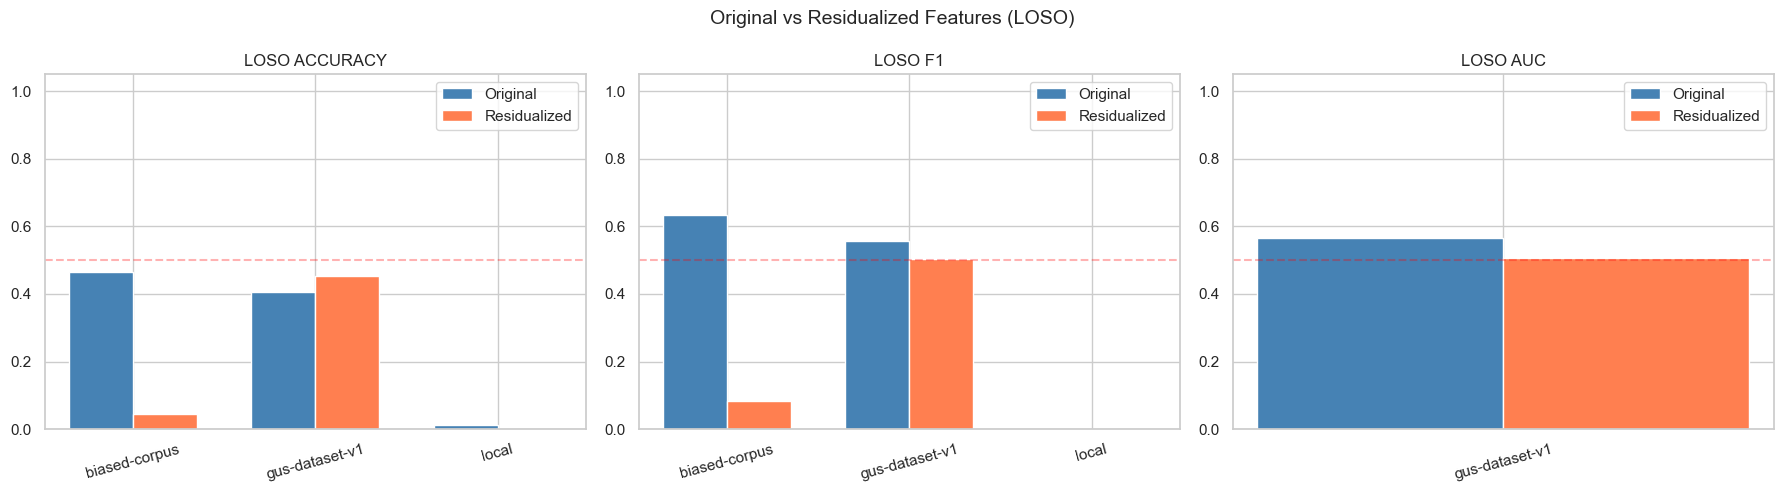

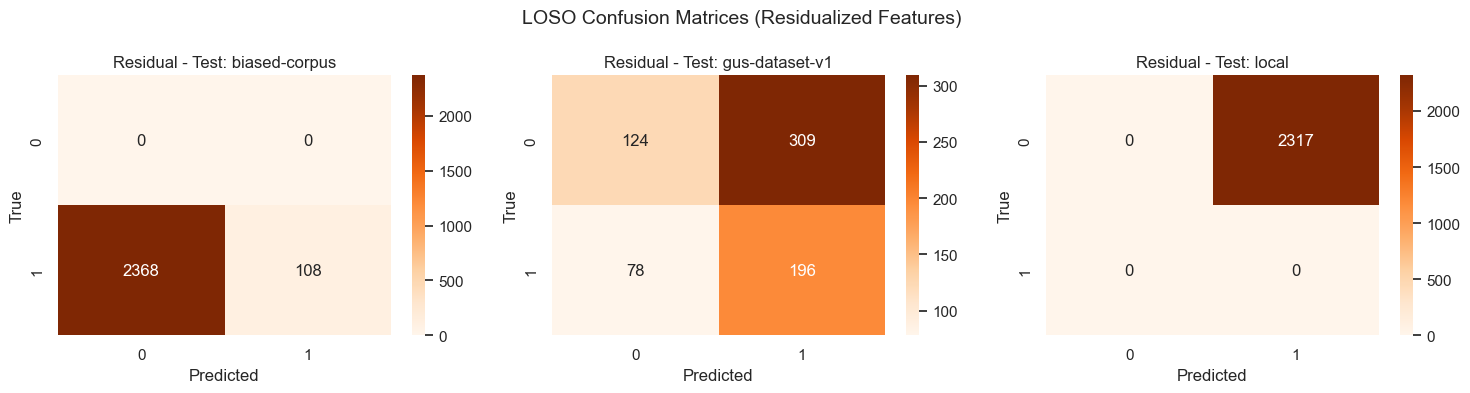

In [82]:
# Side-by-side comparison: Original vs Residualized LOSO
print(f"{'='*70}")
print("COMPARISON: Original Features vs Residualized Features (LOSO)")
print(f"{'='*70}\n")

comparison = df_loso[['test_source', 'accuracy', 'f1', 'auc']].merge(
    df_loso_resid[['test_source', 'accuracy', 'f1', 'auc']],
    on='test_source', suffixes=('_original', '_residual')
)
print(comparison.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(['accuracy', 'f1', 'auc']):
    orig_col = f'{metric}_original'
    resid_col = f'{metric}_residual'
    
    df_plot = comparison[['test_source', orig_col, resid_col]].dropna()
    if len(df_plot) == 0:
        axes[i].set_title(f'{metric.upper()} (no data)')
        continue
    
    x = np.arange(len(df_plot))
    width = 0.35
    axes[i].bar(x - width/2, df_plot[orig_col], width, label='Original', color='steelblue')
    axes[i].bar(x + width/2, df_plot[resid_col], width, label='Residualized', color='coral')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(df_plot['test_source'], rotation=15)
    axes[i].set_title(f'LOSO {metric.upper()}')
    axes[i].set_ylim(0, 1.05)
    axes[i].axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
    axes[i].legend()

plt.suptitle('Original vs Residualized Features (LOSO)', fontsize=14)
plt.tight_layout()
plt.show()

# Plot residualized confusion matrices
n_sources = len(df_loso_resid)
fig, axes_cm = plt.subplots(1, n_sources, figsize=(5 * n_sources, 4))
if n_sources == 1:
    axes_cm = [axes_cm]
for i, row in df_loso_resid.iterrows():
    cm = np.array(row['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes_cm[i])
    axes_cm[i].set_title(f"Residual - Test: {row['test_source']}")
    axes_cm[i].set_xlabel('Predicted')
    axes_cm[i].set_ylabel('True')

plt.suptitle('LOSO Confusion Matrices (Residualized Features)', fontsize=14)
plt.tight_layout()
plt.show()

## 9. Bias Classifier on Residualized Features

Re-train the bias classifier using the **residualized features** (source signal removed).
Same methodology: `GroupShuffleSplit` + `StratifiedGroupKFold` + `HalvingRandomSearchCV`.

- If performance holds → the model learned **real bias signals**
- If performance drops significantly → the model was relying on **source artifacts**

In [83]:
# Group-based train/test split on RESIDUALIZED features (same split indices)
X_train_res = X_residual.iloc[train_idx]
X_test_res = X_residual.iloc[test_idx]
# y_train, y_test, groups_train already defined from Section 7

print(f"Train: {len(X_train_res)} | Test: {len(X_test_res)}")
print(f"Label distribution (train): biased={y_train.sum()}, neutral={(~y_train.astype(bool)).sum()}")
print(f"Label distribution (test):  biased={y_test.sum()}, neutral={(~y_test.astype(bool)).sum()}")

# Model comparison on residualized features
models_res = {
    'LogReg': LogisticRegression(solver='liblinear', max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        tree_method='approx', max_depth=8, n_estimators=500,
        learning_rate=0.05, min_child_weight=1, gamma=0.1,
        reg_alpha=0.1, reg_lambda=1.0, eval_metric='logloss',
        random_state=RANDOM_STATE
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(50,), max_iter=500, early_stopping=True,
        validation_fraction=0.15, n_iter_no_change=15, alpha=0.01,
        random_state=RANDOM_STATE
    )
}

results_res = {}
cv_res = StratifiedGroupKFold(n_splits=5)

print("\nComparing Models on RESIDUALIZED features")
print(f"{'='*80}")
for name, model in models_res.items():
    pipeline = Pipeline([
        ('vt', VarianceThreshold(threshold=0.01)),
        ('s', StandardScaler()),
        ('m', model)
    ])
    scoring = ['roc_auc', 'accuracy', 'precision', 'recall', 'f1']
    scores = cross_validate(
        pipeline, X_train_res, y_train, cv=cv_res, scoring=scoring,
        groups=groups_train
    )
    mean_auc = scores['test_roc_auc'].mean()
    mean_acc = scores['test_accuracy'].mean()
    mean_prec = scores['test_precision'].mean()
    mean_rec = scores['test_recall'].mean()
    mean_f1 = scores['test_f1'].mean()
    results_res[name] = {
        'auc': mean_auc, 'accuracy': mean_acc,
        'precision': mean_prec, 'recall': mean_rec, 'f1': mean_f1
    }
    print(f"{name:15} | AUC: {mean_auc:.4f} | Acc: {mean_acc:.4f} | Prec: {mean_prec:.4f} | Rec: {mean_rec:.4f} | F1: {mean_f1:.4f}")

best_res_name = max(results_res, key=lambda x: results_res[x]['auc'])
print(f"\nBest Model (residualized): {best_res_name} (AUC={results_res[best_res_name]['auc']:.4f})")

# Compare with original
print(f"\n{'='*80}")
print("COMPARISON: Original vs Residualized (CV on train set)")
print(f"{'='*80}")
print(f"{'Model':15} | {'AUC (Orig)':>10} | {'AUC (Resid)':>11} | {'Delta':>8}")
for name in results_res:
    if name in results:
        delta = results_res[name]['auc'] - results[name]['auc']
        print(f"{name:15} | {results[name]['auc']:10.4f} | {results_res[name]['auc']:11.4f} | {delta:+8.4f}")


Train: 4125 | Test: 1375
Label distribution (train): biased=2050, neutral=2075
Label distribution (test):  biased=700, neutral=675

Comparing Models on RESIDUALIZED features
LogReg          | AUC: 0.4549 | Acc: 0.4601 | Prec: 0.4562 | Rec: 0.4483 | F1: 0.4522
RandomForest    | AUC: 0.9955 | Acc: 0.9612 | Prec: 0.9731 | Rec: 0.9483 | F1: 0.9605
XGBoost         | AUC: 0.9967 | Acc: 0.9680 | Prec: 0.9767 | Rec: 0.9585 | F1: 0.9675
MLP             | AUC: 0.9901 | Acc: 0.9535 | Prec: 0.9534 | Rec: 0.9532 | F1: 0.9532

Best Model (residualized): XGBoost (AUC=0.9967)

COMPARISON: Original vs Residualized (CV on train set)
Model           | AUC (Orig) | AUC (Resid) |    Delta
LogReg          |     0.9741 |      0.4549 |  -0.5193
RandomForest    |     0.9611 |      0.9955 |  +0.0344
XGBoost         |     0.9758 |      0.9967 |  +0.0209
MLP             |     0.9766 |      0.9901 |  +0.0135


Tuning XGBoost on residualized features...
Best Params: {'m__n_estimators': 200, 'm__max_depth': 5, 'm__learning_rate': 0.1}

Final Test: RESIDUALIZED Features
AUC:       0.9972
Accuracy:  0.9673
Precision: 0.9781
Recall:    0.9571
F1:        0.9675

Classification Report (Residualized):
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       675
           1       0.98      0.96      0.97       700

    accuracy                           0.97      1375
   macro avg       0.97      0.97      0.97      1375
weighted avg       0.97      0.97      0.97      1375



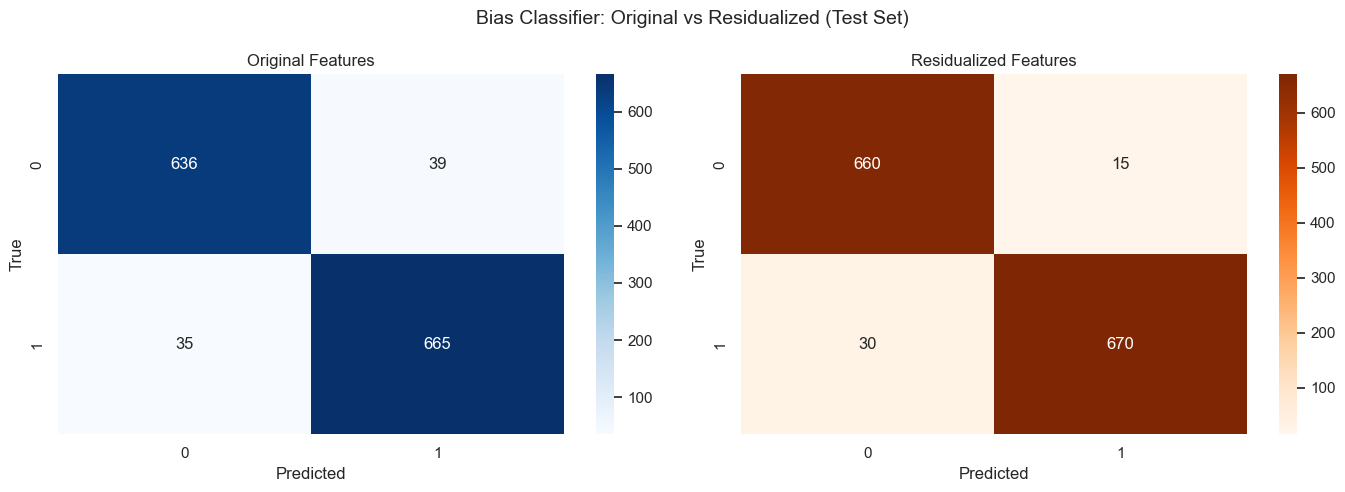


COMPARISON: Original vs Residualized (Test Set)
Metric       |   Original | Residualized |    Delta
--------------------------------------------------
AUC          |     0.9893 |       0.9972 |  +0.0079
Accuracy     |     0.9462 |       0.9673 |  +0.0211
F1           |     0.9473 |       0.9675 |  +0.0202
Precision    |     0.9446 |       0.9781 |  +0.0335
Recall       |     0.9500 |       0.9571 |  +0.0071


In [84]:
# Hyperparameter tuning on residualized features
print(f"Tuning {best_res_name} on residualized features...")

pipeline_res = Pipeline([
    ('vt', VarianceThreshold(threshold=0.01)),
    ('s', StandardScaler()),
    ('m', models_res[best_res_name])
])

cv_tuning_res = StratifiedGroupKFold(n_splits=5)
search_res = HalvingRandomSearchCV(
    pipeline_res,
    param_distributions=param_grids[best_res_name],
    cv=cv_tuning_res,
    scoring='roc_auc',
    n_jobs=1,
    factor=1.5,
    resource='n_samples',
    random_state=RANDOM_STATE
)
search_res.fit(X_train_res, y_train, groups=groups_train)

print(f"Best Params: {search_res.best_params_}")
final_model_res = search_res.best_estimator_

# Final test evaluation on residualized features
y_test_pred_res = final_model_res.predict(X_test_res)
y_test_prob_res = final_model_res.predict_proba(X_test_res)[:, 1]

auc_res = roc_auc_score(y_test, y_test_prob_res)
acc_res = accuracy_score(y_test, y_test_pred_res)
prec_res = precision_score(y_test, y_test_pred_res, zero_division=0)
rec_res = recall_score(y_test, y_test_pred_res, zero_division=0)
f1_res = f1_score(y_test, y_test_pred_res, zero_division=0)

print(f"\n{'='*60}")
print("Final Test: RESIDUALIZED Features")
print(f"{'='*60}")
print(f"AUC:       {auc_res:.4f}")
print(f"Accuracy:  {acc_res:.4f}")
print(f"Precision: {prec_res:.4f}")
print(f"Recall:    {rec_res:.4f}")
print(f"F1:        {f1_res:.4f}")

print(f"\nClassification Report (Residualized):")
print(classification_report(y_test, y_test_pred_res, zero_division=0))

cm_res = confusion_matrix(y_test, y_test_pred_res)

# Side-by-side confusion matrices
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm_orig = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_orig, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Original Features')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')

sns.heatmap(cm_res, annot=True, fmt='d', cmap='Oranges', ax=ax2)
ax2.set_title('Residualized Features')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

plt.suptitle('Bias Classifier: Original vs Residualized (Test Set)', fontsize=14)
plt.tight_layout()
plt.show()

# Compare metrics
print(f"\n{'='*60}")
print("COMPARISON: Original vs Residualized (Test Set)")
print(f"{'='*60}")
orig_auc = roc_auc_score(y_test, y_test_prob)
orig_acc = accuracy_score(y_test, y_test_pred)
orig_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"{'Metric':12} | {'Original':>10} | {'Residualized':>12} | {'Delta':>8}")
print(f"{'-'*50}")
print(f"{'AUC':12} | {orig_auc:10.4f} | {auc_res:12.4f} | {auc_res - orig_auc:+8.4f}")
print(f"{'Accuracy':12} | {orig_acc:10.4f} | {acc_res:12.4f} | {acc_res - orig_acc:+8.4f}")
print(f"{'F1':12} | {orig_f1:10.4f} | {f1_res:12.4f} | {f1_res - orig_f1:+8.4f}")
print(f"{'Precision':12} | {precision_score(y_test, y_test_pred, zero_division=0):10.4f} | {prec_res:12.4f} | {prec_res - precision_score(y_test, y_test_pred, zero_division=0):+8.4f}")
print(f"{'Recall':12} | {recall_score(y_test, y_test_pred, zero_division=0):10.4f} | {rec_res:12.4f} | {rec_res - recall_score(y_test, y_test_pred, zero_division=0):+8.4f}")

ERROR ANALYSIS BY SOURCE: Original vs Residualized

Source               |  Orig Errors |  Resid Errors |  Orig Rate |  Resid Rate
---------------------------------------------------------------------------
biased-corpus        |    21 / 631   |     1 / 631   |      3.3% |       0.2%
gus-dataset-v1       |    32 / 171   |    44 / 171   |     18.7% |      25.7%
local                |    21 / 573   |     0 / 573   |      3.7% |       0.0%
---------------------------------------------------------------------------
TOTAL                |    74 / 1375  |    45 / 1375  |      5.4% |       3.3%


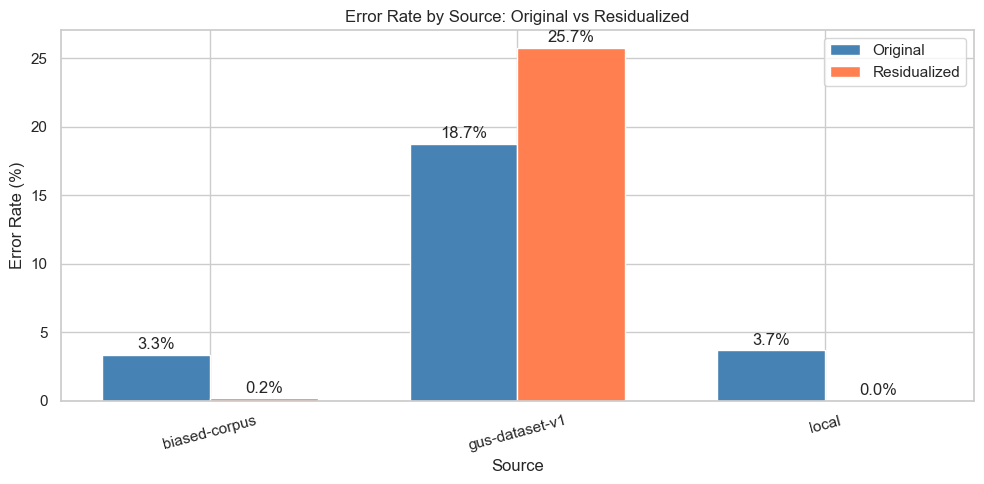

In [85]:
# Error Analysis by Source: Residualized vs Original
test_sources_arr = df_features.iloc[test_idx]['source'].values

errors_orig = y_test.values != y_test_pred
errors_resid = y_test.values != y_test_pred_res

print(f"{'='*70}")
print("ERROR ANALYSIS BY SOURCE: Original vs Residualized")
print(f"{'='*70}")
print(f"\n{'Source':20} | {'Orig Errors':>12} | {'Resid Errors':>13} | {'Orig Rate':>10} | {'Resid Rate':>11}")
print(f"{'-'*75}")

for src in unique_sources:
    src_mask = test_sources_arr == src
    src_total = src_mask.sum()
    orig_errs = (errors_orig & src_mask).sum()
    resid_errs = (errors_resid & src_mask).sum()
    orig_rate = orig_errs / src_total if src_total > 0 else 0
    resid_rate = resid_errs / src_total if src_total > 0 else 0
    print(f"{src:20} | {orig_errs:>5} / {src_total:<5} | {resid_errs:>5} / {src_total:<5} | {orig_rate:>9.1%} | {resid_rate:>10.1%}")

total_orig = errors_orig.sum()
total_resid = errors_resid.sum()
total_n = len(y_test)
print(f"{'-'*75}")
print(f"{'TOTAL':20} | {total_orig:>5} / {total_n:<5} | {total_resid:>5} / {total_n:<5} | {total_orig/total_n:>9.1%} | {total_resid/total_n:>10.1%}")

# Visualize error rates by source
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(unique_sources))
width = 0.35

orig_rates = []
resid_rates = []
for src in unique_sources:
    src_mask = test_sources_arr == src
    src_total = src_mask.sum()
    orig_rates.append((errors_orig & src_mask).sum() / src_total if src_total > 0 else 0)
    resid_rates.append((errors_resid & src_mask).sum() / src_total if src_total > 0 else 0)

bars1 = ax.bar(x - width/2, [r * 100 for r in orig_rates], width, label='Original', color='steelblue')
bars2 = ax.bar(x + width/2, [r * 100 for r in resid_rates], width, label='Residualized', color='coral')

ax.set_xlabel('Source')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Error Rate by Source: Original vs Residualized')
ax.set_xticks(x)
ax.set_xticklabels(unique_sources, rotation=15)
ax.legend()
ax.bar_label(bars1, fmt='%.1f%%', padding=2)
ax.bar_label(bars2, fmt='%.1f%%', padding=2)
plt.tight_layout()
plt.show()

## 10. Conclusions & Interpretation

In [86]:
# Final Summary
print("=" * 70)
print("DIAGNOSTIC SUMMARY")
print("=" * 70)

print(f"""
1. DATASET STRUCTURE
   - 5500 entries from 3 sources (balanced 50/50 bias/neutral)
   - biased-corpus:  2476 entries (100% biased,   0% neutral)
   - local:          2317 entries (  0% biased, 100% neutral)
   - gus-dataset-v1:  707 entries ( 39% biased,  61% neutral)
   - SOURCE and LABEL are almost perfectly confounded

2. LOSO (Original Features)
   - Train on 2 sources, test on held-out source
   - biased-corpus test: {loso_results[0]['accuracy']:.1%} accuracy (nearly all predicted neutral)
   - gus-dataset-v1 test: {loso_results[1]['accuracy']:.1%} accuracy (AUC={loso_results[1]['auc']:.4f})
   - local test: {loso_results[2]['accuracy']:.1%} accuracy (nearly all predicted biased)
   >> Model fails catastrophically on unseen sources

3. SOURCE CLASSIFIER
   - Accuracy: {best_src_acc:.1%} (baseline: {1/len(le.classes_):.1%})
   - Attention features strongly encode source/domain information

4. RESIDUALIZATION
   - Source classifier after residualization: {src_acc_residual:.1%}
   - Bias classifier (original):      AUC={orig_auc:.4f}, F1={orig_f1:.4f}
   - Bias classifier (residualized):   AUC={auc_res:.4f}, F1={f1_res:.4f}
""")

delta_auc = auc_res - orig_auc
if abs(delta_auc) < 0.05:
    interpretation = (
        "INTERPRETATION: Performance is STABLE after residualization.\n"
        "   The bias classifier retains most of its predictive power even after\n"
        "   removing source information. This suggests the model captures\n"
        "   real bias signals beyond source/domain artifacts."
    )
elif delta_auc < -0.05:
    interpretation = (
        "INTERPRETATION: Performance DROPS after residualization.\n"
        "   The bias classifier loses significant predictive power when source\n"
        "   information is removed. This indicates the original model was\n"
        "   partially (or heavily) relying on source/domain artifacts.\n"
        "   The remaining performance reflects the true bias signal."
    )
else:
    interpretation = (
        "INTERPRETATION: Performance IMPROVES after residualization.\n"
        "   Removing source noise may have helped the classifier focus on\n"
        "   genuine bias signals."
    )

print(interpretation)

print(f"""
5. LOSO (Residualized Features)""")
for r in loso_resid_results:
    auc_str = f"AUC={r['auc']:.4f}" if not np.isnan(r['auc']) else "AUC=N/A (single class)"
    print(f"   - {r['test_source']:20} Acc={r['accuracy']:.1%}, F1={r['f1']:.4f}, {auc_str}")

print(f"""
6. ERROR DISTRIBUTION
   Original:      gus-dataset-v1 had highest error rate (domain mismatch)
   Residualized:  check if error rates are more uniform across sources
""")

DIAGNOSTIC SUMMARY

1. DATASET STRUCTURE
   - 5500 entries from 3 sources (balanced 50/50 bias/neutral)
   - biased-corpus:  2476 entries (100% biased,   0% neutral)
   - local:          2317 entries (  0% biased, 100% neutral)
   - gus-dataset-v1:  707 entries ( 39% biased,  61% neutral)
   - SOURCE and LABEL are almost perfectly confounded

2. LOSO (Original Features)
   - Train on 2 sources, test on held-out source
   - biased-corpus test: 46.5% accuracy (nearly all predicted neutral)
   - gus-dataset-v1 test: 40.5% accuracy (AUC=0.5646)
   - local test: 1.2% accuracy (nearly all predicted biased)
   >> Model fails catastrophically on unseen sources

3. SOURCE CLASSIFIER
   - Accuracy: 91.0% (baseline: 33.3%)
   - Attention features strongly encode source/domain information

4. RESIDUALIZATION
   - Source classifier after residualization: 31.1%
   - Bias classifier (original):      AUC=0.9893, F1=0.9473
   - Bias classifier (residualized):   AUC=0.9972, F1=0.9675

INTERPRETATION: Pe

## 11. Out-of-Distribution Probe: Novel Sentences by Contrastive Type

Test the classifier on **new sentences written from scratch** (not from any dataset source), organized in contrasting pairs:

| Pair | Type A | Type B | Same topic, different form |
|------|--------|--------|---------------------------|
| **Question vs Statement** | interrogative | declarative | same bias content |
| **Scientific vs Conversational** | formal/technical | informal/casual | same bias content |

Each pair has a **biased** and a **neutral** version → 4 sentences per pair.
If the model learned real bias, predictions should depend on **bias content**, not on text form.

In [96]:
# ─── Novel contrastive sentence pairs ───
# Each group: same TOPIC, same BIAS label, different FORM
# The model should give the same prediction within each group if it learned bias, not form.

probe_sentences = [
    # ═══ QUESTION vs STATEMENT — BIASED ═══
    {"text": "Why are women so bad at making rational decisions under pressure?",
     "expected": 1, "form": "question",    "contrast": "Q vs S", "topic": "gender rationality"},
    {"text": "Women are incapable of making rational decisions under pressure.",
     "expected": 1, "form": "statement",   "contrast": "Q vs S", "topic": "gender rationality"},

    {"text": "Don't you think immigrants are ruining the job market for locals?",
     "expected": 1, "form": "question",    "contrast": "Q vs S", "topic": "immigration jobs"},
    {"text": "Immigrants are ruining the job market for locals.",
     "expected": 1, "form": "statement",   "contrast": "Q vs S", "topic": "immigration jobs"},

    # ═══ QUESTION vs STATEMENT — NEUTRAL ═══
    {"text": "How many languages are spoken across the African continent?",
     "expected": 0, "form": "question",    "contrast": "Q vs S", "topic": "African languages"},
    {"text": "Over two thousand languages are spoken across the African continent.",
     "expected": 0, "form": "statement",   "contrast": "Q vs S", "topic": "African languages"},

    {"text": "What percentage of the global population lives in urban areas?",
     "expected": 0, "form": "question",    "contrast": "Q vs S", "topic": "urbanization"},
    {"text": "About 56 percent of the global population lives in urban areas.",
     "expected": 0, "form": "statement",   "contrast": "Q vs S", "topic": "urbanization"},

    # ═══ SCIENTIFIC vs CONVERSATIONAL — BIASED ═══
    {"text": "Empirical evidence consistently demonstrates that elderly individuals exhibit diminished cognitive processing speed.",
     "expected": 1, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "age cognition"},
    {"text": "Old people are slow thinkers, everyone knows that.",
     "expected": 1, "form": "conversational", "contrast": "Sci vs Conv", "topic": "age cognition"},

    {"text": "Cross-cultural analyses indicate that populations from developing nations display lower intellectual aptitude.",
     "expected": 1, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "nationality intelligence"},
    {"text": "People from poor countries are just not as smart as us.",
     "expected": 1, "form": "conversational", "contrast": "Sci vs Conv", "topic": "nationality intelligence"},

    # ═══ SCIENTIFIC vs CONVERSATIONAL — NEUTRAL ═══
    {"text": "Systematic reviews of randomized trials confirm that aerobic exercise reduces resting blood pressure.",
     "expected": 0, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "exercise health"},
    {"text": "Going for a run a few times a week helps keep your blood pressure down.",
     "expected": 0, "form": "conversational", "contrast": "Sci vs Conv", "topic": "exercise health"},

    {"text": "Longitudinal meteorological data show an upward trend in average surface temperatures globally.",
     "expected": 0, "form": "scientific",  "contrast": "Sci vs Conv", "topic": "temperature trend"},
    {"text": "It seems like summers keep getting hotter every year around the world.",
     "expected": 0, "form": "conversational", "contrast": "Sci vs Conv", "topic": "temperature trend"},
]

print(f"Probe sentences: {len(probe_sentences)}")
print(f"  Biased: {sum(1 for s in probe_sentences if s['expected']==1)}")
print(f"  Neutral: {sum(1 for s in probe_sentences if s['expected']==0)}")

# ─── Extract features ───
print("\nLoading BERT model...")
manager = ModelManager()

print("Extracting features...")
probe_features = []
for i, item in enumerate(probe_sentences):
    feats = extract_features_for_sentence(item["text"], "bert-base-uncased", manager)
    probe_features.append(feats)
    print(f"  [{i+1:2d}/{len(probe_sentences)}] done")

df_probe = pd.DataFrame(probe_features)

# Align columns
missing = set(X_final.columns) - set(df_probe.columns)
extra = set(df_probe.columns) - set(X_final.columns)
for c in missing:
    df_probe[c] = 0.0
if extra:
    df_probe = df_probe.drop(columns=list(extra))
df_probe = df_probe[X_final.columns]
print(f"Features aligned: {df_probe.shape}")

# ─── Predict ───
pred = final_model.predict(df_probe)
prob = final_model.predict_proba(df_probe)[:, 1]

# ─── Display results by contrast group ───
from itertools import groupby

print(f"\n{'='*110}")
print("CONTRASTIVE PROBE RESULTS")
print(f"{'='*110}")

for contrast_name in ["Q vs S", "Sci vs Conv"]:
    group = [s for s in probe_sentences if s["contrast"] == contrast_name]
    group_idx = [i for i, s in enumerate(probe_sentences) if s["contrast"] == contrast_name]

    label_map = {1: "biased", 0: "neutral"}
    contrast_full = "QUESTION vs STATEMENT" if contrast_name == "Q vs S" else "SCIENTIFIC vs CONVERSATIONAL"
    print(f"\n{'─'*110}")
    print(f"  {contrast_full}")
    print(f"{'─'*110}")

    # Group by topic
    topics_seen = []
    for s in group:
        if s["topic"] not in topics_seen:
            topics_seen.append(s["topic"])

    for topic in topics_seen:
        pair = [(i, s) for i, s in zip(group_idx, group) if s["topic"] == topic]
        exp_label = label_map[pair[0][1]["expected"]]
        print(f"\n  Topic: {topic} (expected: {exp_label})")
        for idx, s in pair:
            p = pred[idx]
            pr = prob[idx]
            ok = "OK" if p == s["expected"] else "MISS"
            pred_label = "biased" if p == 1 else "neutral"
            print(f"    [{s['form']:14s}] P(bias)={pr:.3f}  pred={pred_label:7s} {ok:4s}  \"{s['text'][:75]}\"")

# ─── Summary stats ───
correct = sum(1 for i, s in enumerate(probe_sentences) if pred[i] == s["expected"])
n = len(probe_sentences)
print(f"\n{'='*110}")
print(f"Overall accuracy: {correct}/{n} ({correct/n:.0%})")

# Per contrast
for cname in ["Q vs S", "Sci vs Conv"]:
    idxs = [i for i, s in enumerate(probe_sentences) if s["contrast"] == cname]
    c = sum(1 for i in idxs if pred[i] == probe_sentences[i]["expected"])
    print(f"  {cname:15s}: {c}/{len(idxs)}")

# Check consistency: within same topic, do both forms get same prediction?
print(f"\nForm consistency (same topic → same prediction?):")
topics_seen = []
for s in probe_sentences:
    if s["topic"] not in topics_seen:
        topics_seen.append(s["topic"])

consistent = 0
for topic in topics_seen:
    idxs = [i for i, s in enumerate(probe_sentences) if s["topic"] == topic]
    preds_topic = [pred[i] for i in idxs]
    if len(set(preds_topic)) == 1:
        consistent += 1
        print(f"  {topic:30s}: CONSISTENT (both → {'biased' if preds_topic[0]==1 else 'neutral'})")
    else:
        print(f"  {topic:30s}: INCONSISTENT ({[('biased' if p==1 else 'neutral') for p in preds_topic]})")

print(f"\n  Consistent: {consistent}/{len(topics_seen)} topics")
if consistent < len(topics_seen):
    print(f"  >> Model predictions change with text FORM, not just bias CONTENT — suggests sensitivity to style/domain.")

Probe sentences: 16
  Biased: 8
  Neutral: 8

Loading BERT model...
Extracting features...
Loading model: bert-base-uncased...
  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done
Features aligned: (16, 3238)

CONTRASTIVE PROBE RESULTS

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  QUESTION vs STATEMENT
──────────────────────────────────────────────────────────────────────────────────────────────────────────────

  Topic: gender rationality (expected: biased)
    [question      ] P(bias)=0.999  pred=biased  OK    "Why are women so bad at making rational decisions under pressure?"
    [statement     ] P(bias)=0.999  pred=biased  OK    "Women are incapable of making rational decisions under pressure."

  Topic: immigration jobs (expected:

In [97]:
# Save the trained model
import joblib
import os

# Create directory if it doesn't exist
os.makedirs('saved_models', exist_ok=True)

model_path = os.path.join('saved_models', 'bert_bias_classifier.joblib')
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")


Model saved to saved_models\bert_bias_classifier.joblib


In [101]:
# ─── Teste com exemplos específicos (biased vs neutral, mesmo tópico) ───
# Usa final_model e manager já carregados nas cells anteriores

test_examples = [
    # ═══ PAR 1: Género em customer support ═══
    {"text": "For a customer support role, women are usually a safer choice because they tend to be more patient and caring.",
     "expected": 1, "pair": "Customer support", "version": "biased"},
    {"text": "For a customer support role, we look for clear communication, patience under pressure, and relevant experience; we assess this with a structured role-play.",
     "expected": 0, "pair": "Customer support", "version": "neutral"},

    # ═══ PAR 2: Idade e software ═══
    {"text": "If the team includes older employees, it's better to avoid frequent software changes because they often take longer to adapt.",
     "expected": 1, "pair": "Software adoption", "version": "biased"},
    {"text": "Before rolling out frequent software changes, provide training and time to adapt, especially for people who do not use the tool daily.",
     "expected": 0, "pair": "Software adoption", "version": "neutral"},

    # ═══ PAR 3: Sotaque e contratação ═══
    {"text": "The applicant has a strong foreign accent, so clients might not take him seriously.",
     "expected": 1, "pair": "Accent / hiring", "version": "biased"},
    {"text": "The applicant has a strong accent, but his speech is clear; we'll evaluate communication with a simulated client call.",
     "expected": 0, "pair": "Accent / hiring", "version": "neutral"},

    # ═══ Exemplos avulsos — BIASED ═══
    {"text": "The problem with CEOs is that they are greedy.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Men are inherently promiscuous.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "All CEO are fake.",
     "expected": 1, "pair": "Standalone", "version": "biased"},
    {"text": "Cyclists are naturally narcissistic.",
     "expected": 1, "pair": "Standalone", "version": "biased"},

    # ═══ Exemplos avulsos — NEUTRAL ═══
    {"text": 'Trump, who has faced criticism over his handling of the pandemic, said China must be "held accountable" for failing to contain the disease.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Does this research reveal any trends regarding the prevalence of mental health conditions coexisting with physical disabilities?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": 'It is therefore no surprise that Ocasio-Cortez has embraced the term "Democratic socialism.',
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Thermal energy transfers through conduction, convection, and radiation.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "Caffeine can increase alertness and energy levels.",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
    {"text": "What long-term effects might result from using hormone treatments aimed at increasing height during adolescence?",
     "expected": 0, "pair": "Standalone", "version": "neutral"},
]

print(f"Test examples: {len(test_examples)} ({sum(1 for e in test_examples if e['expected']==1)} biased, {sum(1 for e in test_examples if e['expected']==0)} neutral)\n")

# ─── Extract features ───
print("Extracting features...")
feats_list = []
for i, ex in enumerate(test_examples):
    f = extract_features_for_sentence(ex["text"], "bert-base-uncased", manager)
    feats_list.append(f)
    print(f"  [{i+1:2d}/{len(test_examples)}] done")

df_ex = pd.DataFrame(feats_list)
missing = set(X_final.columns) - set(df_ex.columns)
for c in missing:
    df_ex[c] = 0.0
extra = set(df_ex.columns) - set(X_final.columns)
if extra:
    df_ex = df_ex.drop(columns=list(extra))
df_ex = df_ex[X_final.columns]

# ─── Predict ───
preds = final_model.predict(df_ex)
probs = final_model.predict_proba(df_ex)[:, 1]

# ─── Show paired results ───
label = {1: "biased", 0: "neutral"}
print(f"\n{'='*115}")
print("RESULTS")
print(f"{'='*115}")

# First show the 3 contrastive pairs
pairs_shown = []
for ex in test_examples:
    if ex["pair"] != "Standalone" and ex["pair"] not in pairs_shown:
        pairs_shown.append(ex["pair"])

for pair_name in pairs_shown:
    pair_items = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == pair_name]
    print(f"\n  ┌─ {pair_name}")
    for idx, ex in pair_items:
        ok = "OK" if preds[idx] == ex["expected"] else "MISS"
        print(f"  │  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  pred={label[preds[idx]]:7s} exp={label[ex['expected']]:7s} {ok:4s}  \"{ex['text'][:80]}\"")
    # Consistency check
    pred_set = set(preds[i] for i, _ in pair_items)
    exp_set = set(e["expected"] for _, e in pair_items)
    if len(exp_set) > 1 and pred_set == exp_set:
        print(f"  └─ CONSISTENT: model distinguishes biased from neutral")
    elif len(pred_set) == 1 and len(exp_set) > 1:
        print(f"  └─ INCONSISTENT: both predicted as {label[list(pred_set)[0]]}")
    else:
        print(f"  └─ predictions: {[label[preds[i]] for i, _ in pair_items]}")

# Then standalone
print(f"\n  ── Standalone examples ──")
standalone = [(i, e) for i, e in enumerate(test_examples) if e["pair"] == "Standalone"]
for idx, ex in standalone:
    ok = "OK" if preds[idx] == ex["expected"] else "MISS"
    print(f"  [{ex['version']:7s}] P(bias)={probs[idx]:.3f}  pred={label[preds[idx]]:7s} exp={label[ex['expected']]:7s} {ok:4s}  \"{ex['text'][:85]}\"")

# ─── Summary ───
correct = sum(1 for i, e in enumerate(test_examples) if preds[i] == e["expected"])
n = len(test_examples)
biased_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 1 and preds[i] == 1)
neutral_ok = sum(1 for i, e in enumerate(test_examples) if e["expected"] == 0 and preds[i] == 0)
n_b = sum(1 for e in test_examples if e["expected"] == 1)
n_n = sum(1 for e in test_examples if e["expected"] == 0)

print(f"\n{'='*115}")
print(f"Accuracy:           {correct}/{n} ({correct/n:.0%})")
print(f"Biased recall:      {biased_ok}/{n_b} ({biased_ok/n_b:.0%})")
print(f"Neutral specificity: {neutral_ok}/{n_n} ({neutral_ok/n_n:.0%})")

Test examples: 16 (7 biased, 9 neutral)

Extracting features...
  [ 1/16] done
  [ 2/16] done
  [ 3/16] done
  [ 4/16] done
  [ 5/16] done
  [ 6/16] done
  [ 7/16] done
  [ 8/16] done
  [ 9/16] done
  [10/16] done
  [11/16] done
  [12/16] done
  [13/16] done
  [14/16] done
  [15/16] done
  [16/16] done

RESULTS

  ┌─ Customer support
  │  [biased ] P(bias)=0.510  pred=biased  exp=biased  OK    "For a customer support role, women are usually a safer choice because they tend "
  │  [neutral] P(bias)=0.146  pred=neutral exp=neutral OK    "For a customer support role, we look for clear communication, patience under pre"
  └─ CONSISTENT: model distinguishes biased from neutral

  ┌─ Software adoption
  │  [biased ] P(bias)=0.882  pred=biased  exp=biased  OK    "If the team includes older employees, it's better to avoid frequent software cha"
  │  [neutral] P(bias)=0.454  pred=neutral exp=neutral OK    "Before rolling out frequent software changes, provide training and time to adapt"
  └─ CO

In [2]:
from IPython.display import display
import pandas as pd

rows = [
    ('Início', 'Frases no dataset v6', '10 416'),
    ('1. Auditoria automática (Prompt 1)', 'CORRECT', '8 121'),
    ('', 'MISLABELED (label errado)', '935'),
    ('', 'WEAK_BIAS (bias ambíguo/fraco)', '1 360'),
    ('2. Correção automática (Prompt 2)', 'FLIP → corrige label', '935'),
    ('', 'STRENGTHEN → reforça bias', '1 360'),
    ('3. Re-auditoria (Prompt 1, 2.ª passagem)', 'CORRECT', '10 144'),
    ('', 'Ainda flagged', '272'),
    ('4. Revisão manual', 'Corrigidos', '160'),
    ('', 'Removidos', '112'),
    ('Dataset final (v9)', 'Total de frases', '10 304'),
    ('', 'original — sem alterações', '5 094'),
    ('', 'counterfactual — geradas como CF', '2 926'),
    ('', 'strengthened — bias reforçado', '1 349'),
    ('', 'relabelled_only — label corrigido', '935'),
]

df_curation = pd.DataFrame(rows, columns=['Etapa', 'Detalhe', 'N'])

display(df_curation.style
    .set_properties(**{'text-align': 'left'}, subset=['Etapa', 'Detalhe'])
    .set_properties(**{'text-align': 'right'}, subset=['N'])
    .set_properties(**{'font-weight': 'bold'}, subset=pd.IndexSlice[
        df_curation[df_curation['Etapa'] != ''].index, ['Etapa']
    ])
    .hide(axis='index')
    .set_caption('Evolução da curadoria do dataset v9')
)


Etapa,Detalhe,N
Início,Frases no dataset v6,10 416
1. Auditoria automática (Prompt 1),CORRECT,8 121
,MISLABELED (label errado),935
,WEAK_BIAS (bias ambíguo/fraco),1 360
2. Correção automática (Prompt 2),FLIP → corrige label,935
,STRENGTHEN → reforça bias,1 360
"3. Re-auditoria (Prompt 1, 2.ª passagem)",CORRECT,10 144
,Ainda flagged,272
4. Revisão manual,Corrigidos,160
,Removidos,112
